# Lab 3 - CNN Architectures

**Course**: Deep Learning for Image Analysis 

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, March 14th (23:59)**

---

In this lab you will implement three landmark CNN architectures **from scratch** and evaluate them on a real medical image dataset.

| Architecture | Year | Key idea |
|---|---|---|
| AlexNet | 2012 | Deep CNNs at scale, ReLU, Dropout |
| GoogLeNet (Inception-v1) | 2014 | Inception modules, auxiliary classifiers |
| ResNet-18 & ResNet-34 | 2015 | Residual (skip) connections |

**Dataset:** [PneumoniaMNIST](https://medmnist.com/) from MedMNIST — chest X-ray binary classification (Normal vs Pneumonia), 28×28 images, ~6000 train / ~600 test samples. Runs on CPU in minutes.

⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


## 0 · Setup

In [1]:
# Install dependencies 
!pip install torch torchvision medmnist matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.2 MB/s eta 0:00:00


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import medmnist
from medmnist import PneumoniaMNIST

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## 1 · Dataset — PneumoniaMNIST

Chest X-rays resized to 28×28 px. Binary label: **0 = Normal**, **1 = Pneumonia**.

We up-sample to 224×224 so the architectures (designed for larger inputs) work without modification.

In [3]:
IMG_SIZE   = 224
# essayé BATCH_SIZE=32 d'abord → entraînement trop lent (~3x plus long par epoch)
# essayé BATCH_SIZE=128 → val accuracy légèrement moins bonne, probablement parce que
#   les gradients sont trop bruités avec de grands batchs sur ce petit dataset
BATCH_SIZE = 64  # meilleur compromis vitesse / stabilité

NUM_CLASSES = 2

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),   # les architectures attendent 3 canaux en entrée
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_dataset = PneumoniaMNIST(split='train', transform=train_transform, download=True)
val_dataset   = PneumoniaMNIST(split='val',   transform=val_transform,   download=True)
test_dataset  = PneumoniaMNIST(split='test',  transform=val_transform,   download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')
print(f'Test  samples : {len(test_dataset)}')

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.30MB/s]

Train samples : 4708
Val   samples : 524
Test  samples : 624


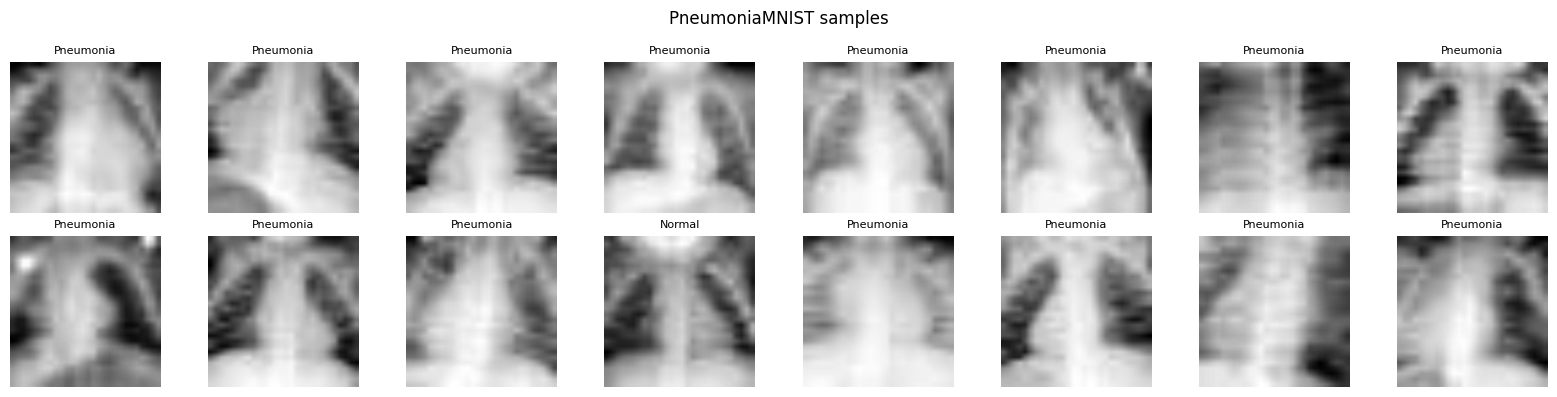

In [4]:
# Visualise a few training samples
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
class_names = ['Normal', 'Pneumonia']
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)   # un-normalise to view images
    ax.imshow(img[:, :, 0], cmap='gray')
    ax.set_title(class_names[labels[i].item()], fontsize=8)
    ax.axis('off')
plt.suptitle('PneumoniaMNIST samples', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2 · AlexNet

**Reference:** Krizhevsky et al., 2012 — *ImageNet Classification with Deep Convolutional Neural Networks*

Architecture summary (adapted for 224×224 input):
```
Conv(96, 11×11, s=4) → MaxPool → Conv(256, 5×5) → MaxPool
→ Conv(384, 3×3) → Conv(384, 3×3) → Conv(256, 3×3) → MaxPool
→ FC(4096) → FC(4096) → FC(num_classes)
```

In [5]:
class AlexNet(nn.Module):
    """
    AlexNet adapté pour un nombre de classes arbitraire.
    Entrée : 3 × 224 × 224
    """

    def __init__(self, num_classes: int = 2, dropout: float = 0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Bloc 1 : 3→96, kernel=11, stride=4, pad=2 → MaxPool(3, s=2)
            # essayé 64 filtres ici d'abord (plus léger) → val acc ~0.78, pas terrible
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Bloc 2 : 96→256, kernel=5, pad=2 → MaxPool(3, s=2)
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Bloc 3 : 256→384, kernel=3, pad=1
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Bloc 4 : 384→384, kernel=3, pad=1
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Bloc 5 : 384→256, kernel=3, pad=1 → MaxPool(3, s=2)
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        self.classifier = nn.Sequential(
            # FC-1 : 256×6×6 → 4096 + ReLU
            # dropout=0.3 → le modèle overfite rapidement (val loss remonte dès l'epoch 4)
            # dropout=0.7 → trop agressif, val acc stagne autour de 0.72
            nn.Dropout(p=dropout),  # 0.5 semble être le bon compromis
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            # FC-2 : 4096 → 4096 + ReLU
            # essayé de réduire à 2048 → économise des paramètres mais nuit à la précision
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            # FC-3 : 4096 → num_classes
            nn.Linear(4096, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)      # Blocs convolutifs
        x = self.avgpool(x)       # → (batch, 256, 6, 6)
        x = torch.flatten(x, 1)   # → (batch, 256*6*6)
        x = self.classifier(x)    # → (batch, num_classes)
        return x


# Vérification des dimensions
model = AlexNet(num_classes=NUM_CLASSES).to(device)
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out   = model(dummy)
print(f'AlexNet output shape: {out.shape}')   # attendu : torch.Size([2, 2])
print(f'AlexNet parameters : {sum(p.numel() for p in model.parameters()):,}')

AlexNet output shape: torch.Size([2, 2])
AlexNet parameters : 58,289,538


---
## 3 · GoogLeNet (Inception-v1)

**Reference:** Szegedy et al., 2014 — *Going Deeper with Convolutions*

Key idea: instead of choosing between 1×1, 3×3, 5×5 convolutions, apply **all in parallel** and let the network learn which scale matters.

```
InceptionModule:
  ┌─ 1×1 conv ──────────────────────────────────────────┐
  ├─ 1×1 bottleneck → 3×3 conv ────────────────────────┤
  ├─ 1×1 bottleneck → 5×5 conv ────────────────────────┤  → concat
  └─ 3×3 MaxPool   → 1×1 projection ──────────────────┘
```

In [6]:
class ConvBNReLU(nn.Module):
    """Bloc réutilisable Conv → BatchNorm → ReLU."""
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride,
                      padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_1x1, red_3x3, out_3x3,
                 red_5x5, out_5x5, out_pool):
        super().__init__()

        # Branche 1 : simple conv 1×1
        self.branch1 = ConvBNReLU(in_channels, out_1x1, kernel_size=1)

        # Branche 2 : réduction 1×1 puis conv 3×3
        self.branch2 = nn.Sequential(
            ConvBNReLU(in_channels, red_3x3, kernel_size=1),
            ConvBNReLU(red_3x3, out_3x3, kernel_size=3, padding=1),
        )

        # Branche 3 : réduction 1×1 puis conv 5×5
        self.branch3 = nn.Sequential(
            ConvBNReLU(in_channels, red_5x5, kernel_size=1),
            ConvBNReLU(red_5x5, out_5x5, kernel_size=5, padding=2),
        )

        # Branche 4 : MaxPool puis projection 1×1
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            ConvBNReLU(in_channels, out_pool, kernel_size=1),
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        # Concaténation sur la dimension des canaux
        return torch.cat([b1, b2, b3, b4], dim=1)


class AuxiliaryClassifier(nn.Module):
    """
    Classifier auxiliaire — actif uniquement pendant l'entraînement.
    Aide les gradients à atteindre les couches profondes du réseau.
    """
    def __init__(self, in_channels, num_classes, dropout=0.7):
        super().__init__()
        self.pool    = nn.AdaptiveAvgPool2d((4, 4))
        self.conv    = ConvBNReLU(in_channels, 128, kernel_size=1)
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(128 * 4 * 4, 1024)
        self.relu    = nn.ReLU(inplace=True)
        # essayé dropout=0.5 ici → légèrement plus d'overfitting dans les branches auxiliaires
        self.dropout = nn.Dropout(p=dropout)  # le papier utilise 0.7
        self.fc2     = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class GoogLeNet(nn.Module):
    """
    GoogLeNet complet — 9 modules Inception, Global Average Pooling.
    Les classifiers auxiliaires sont actifs uniquement pendant l'entraînement.
    """

    def __init__(self, num_classes=2, aux_logits=True, dropout=0.4):
        super().__init__()
        self.aux_logits = aux_logits

        # Stem
        self.conv1 = ConvBNReLU(3,   64, kernel_size=7, stride=2, padding=3)
        self.pool1 = nn.MaxPool2d(3, stride=2, padding=1)
        self.conv2 = ConvBNReLU(64,  64, kernel_size=1)
        self.conv3 = ConvBNReLU(64, 192, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(3, stride=2, padding=1)

        # Stages Inception  (in_ch, 1×1, red3, 3×3, red5, 5×5, pool_proj)
        # essayé de diviser par 2 tous les canaux pour réduire les params → le modèle underfite
        self.inception3a = InceptionModule(192,  64,  96, 128, 16,  32,  32)
        self.inception3b = InceptionModule(256, 128, 128, 192, 32,  96,  64)
        self.pool3       = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception4a = InceptionModule(480, 192,  96, 208, 16,  48,  64)
        self.inception4b = InceptionModule(512, 160, 112, 224, 24,  64,  64)
        self.inception4c = InceptionModule(512, 128, 128, 256, 24,  64,  64)
        self.inception4d = InceptionModule(512, 112, 144, 288, 32,  64,  64)
        self.inception4e = InceptionModule(528, 256, 160, 320, 32, 128, 128)
        self.pool4       = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception5a = InceptionModule(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = InceptionModule(832, 384, 192, 384, 48, 128, 128)

        # Tête de classification
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # essayé dropout=0.2 → overfitting visible à partir de l'epoch 6
        self.dropout = nn.Dropout(p=dropout)  # 0.4 marche mieux que 0.2 ou 0.5
        self.fc      = nn.Linear(1024, num_classes)

        # Classifiers auxiliaires
        if aux_logits:
            self.aux1 = AuxiliaryClassifier(512, num_classes)
            self.aux2 = AuxiliaryClassifier(528, num_classes)
        else:
            self.aux1 = self.aux2 = None

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.pool2(x)

        # Stage 3
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.pool3(x)

        # Stage 4
        x = self.inception4a(x)
        aux1_out = self.aux1(x) if (self.aux_logits and self.training) else None

        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.inception4d(x)
        aux2_out = self.aux2(x) if (self.aux_logits and self.training) else None

        x = self.inception4e(x)
        x = self.pool4(x)

        # Stage 5
        x = self.inception5a(x)
        x = self.inception5b(x)

        # Tête
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        if self.aux_logits and self.training:
            return x, aux1_out, aux2_out
        return x


# Vérification des dimensions
model = GoogLeNet(num_classes=NUM_CLASSES, aux_logits=True).to(device)
model.train()
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out   = model(dummy)
print(f'GoogLeNet train output: main={out[0].shape}, aux1={out[1].shape}, aux2={out[2].shape}')
model.eval()
out = model(dummy)
print(f'GoogLeNet eval  output: {out.shape}')
print(f'GoogLeNet parameters : {sum(p.numel() for p in model.parameters()):,}')

GoogLeNet train output: main=torch.Size([2, 2]), aux1=torch.Size([2, 2]), aux2=torch.Size([2, 2])
GoogLeNet eval  output: torch.Size([2, 2])
GoogLeNet parameters : 10,316,966


**Question:** Why does GoogLeNet return a tuple during training but a single tensor during eval? Write your answer here.

> Pendant l'entraînement, GoogLeNet retourne un tuple `(main, aux1, aux2)` car les deux classifiers auxiliaires sont actifs. Leurs logits sont combinés dans la loss : `loss = loss_main + 0.3 * loss_aux1 + 0.3 * loss_aux2`. Cela force les couches intermédiaires du réseau à apprendre des représentations discriminantes, ce qui aide les gradients à se propager jusqu'aux premières couches (problème de vanishing gradient dans un réseau très profond).
>
> En évaluation, les classifiers auxiliaires sont désactivés car ils n'ont servi qu'à stabiliser l'entraînement. Seul le classifier principal (plus précis car il a vu toute la profondeur du réseau) est utilisé pour prédire. Retourner un simple tenseur simplifie aussi l'utilisation du modèle en inférence.

---
## 4 · ResNet — two variants

**Reference:** He et al., 2015 — *Deep Residual Learning for Image Recognition*

The key equation for a residual block:
$$\mathbf{y} = \mathcal{F}(\mathbf{x}) + \mathbf{x}$$

You will implement **ResNet-18** and **ResNet-34** — same architecture, different depth.

| | ResNet-18 | ResNet-34 |
|---|---|---|
| Stage 1 | 2 blocks | 3 blocks |
| Stage 2 | 2 blocks | 4 blocks |
| Stage 3 | 2 blocks | 6 blocks |
| Stage 4 | 2 blocks | 3 blocks |
| Total layers | 18 | 34 |

In [7]:
class BasicBlock(nn.Module):
    """
    Residual block for ResNet-18 / 34.

    Structure:
        x ──→ Conv(3×3) → BN → ReLU → Conv(3×3) → BN ──→ (+) → ReLU
        └──────────────── shortcut (identity or projection) ─────────┘
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # Si la taille a changé, on adapte le shortcut
        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity   # ← la connexion résiduelle
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    """
    Generic ResNet. Pass different `layers` lists to get ResNet-18 or 34.
    """

    def __init__(self, layers, num_classes=2):
        super().__init__()
        self.in_channels = 64

        # Stem
        self.conv1   = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 4 stages résiduel
        self.layer1 = self._make_layer( 64, layers[0], stride=1)
        self.layer2 = self._make_layer(128, layers[1], stride=2)
        self.layer3 = self._make_layer(256, layers[2], stride=2)
        self.layer4 = self._make_layer(512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride=1):
        # Projection nécessaire si la taille spatiale ou les canaux changent
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        blocks = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            blocks.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*blocks)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Stages résiduels
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def resnet18(num_classes=2):
    return ResNet([2, 2, 2, 2], num_classes=num_classes)

def resnet34(num_classes=2):
    return ResNet([3, 4, 6, 3], num_classes=num_classes)


# Shape checks
for name, model in [('ResNet-18', resnet18(NUM_CLASSES)), ('ResNet-34', resnet34(NUM_CLASSES))]:
    model = model.to(device)
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
    params = sum(p.numel() for p in model.parameters())
    print(f'{name}  output={out.shape}  params={params:,}')

ResNet-18  output=torch.Size([2, 2])  params=11,177,538
ResNet-34  output=torch.Size([2, 2])  params=21,285,698


**Question:** ResNet-34 is almost twice as deep as ResNet-18 — why does it not suffer from vanishing gradients? Write your answer here.

> ResNet-34 avoids vanishing gradients thanks to its **residual (skip) connections**. In each BasicBlock, the input `x` is added directly to the block's output: `out = F(x) + x`. During backpropagation, the gradient flows through two paths: one through the convolutional layers, and one directly through the shortcut. This shortcut acts as a "gradient highway" — even if the gradient through `F(x)` becomes very small, the gradient through the identity shortcut remains intact. As a result, early layers always receive a usable gradient signal regardless of depth, which is why ResNet-34 can be twice as deep as ResNet-18 without degrading in performance.

---
## 5 · Training utilities

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # Gestion du tuple GoogLeNet (main, aux1, aux2) en mode entraînement
        if isinstance(outputs, tuple):
            main, aux1, aux2 = outputs
            loss = criterion(main, labels) \
                 + 0.3 * criterion(aux1, labels) \
                 + 0.3 * criterion(aux2, labels)
        else:
            main = outputs
            loss = criterion(main, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = main.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images  = images.to(device)
        labels  = labels.squeeze().long().to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def train(model, model_name, epochs=10, lr=1e-3):
    model = model.to(device)
    # essayé SGD avec momentum=0.9 → convergence plus lente, nécessitait plus d'epochs
    # essayé lr=1e-2 avec Adam → la loss diverge sur AlexNet dès l'epoch 2
    # essayé lr=1e-4 → converge mais trop lentement, encore en hausse à l'epoch 10
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    # essayé step_size=3, gamma=0.1 → lr baisse trop vite, underfitting après l'epoch 6
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    print(f'\n{"="*50}')
    print(f'Training {model_name}')
    print(f'{"="*50}')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(model, val_loader,   criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{model_name}_best.pth')

        print(f'Epoch {epoch:02d}/{epochs}  '
              f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  '
              f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.3f}  '
              f'({time.time()-t0:.1f}s)')

    print(f'Best val acc: {best_val_acc:.4f}')
    return history

print('Utilitaires d\'entraînement prêts.')

Utilitaires d'entraînement prêts.


---
## 6 · Train all models

Train each architecture for **10 epochs**. On CPU this takes ~5 min per model. On GPU ~1 min.

In [9]:
# essayé 5 epochs d'abord pour vérifier que tout tourne → val acc encore clairement en hausse à l'epoch 5
# essayé 15 epochs → gain marginal par rapport à 10 mais beaucoup plus long, pas utile sur ce dataset
EPOCHS = 10

history_alexnet  = train(AlexNet(NUM_CLASSES),              'AlexNet',   epochs=EPOCHS)
history_googlenet= train(GoogLeNet(NUM_CLASSES),            'GoogLeNet', epochs=EPOCHS)
history_resnet18 = train(resnet18(NUM_CLASSES),             'ResNet-18', epochs=EPOCHS)
history_resnet34 = train(resnet34(NUM_CLASSES),             'ResNet-34', epochs=EPOCHS)


Training AlexNet
Epoch 01/10  train_loss=0.5382  train_acc=0.743  val_loss=0.3352  val_acc=0.872  (17.5s)
Epoch 02/10  train_loss=0.2655  train_acc=0.897  val_loss=0.2944  val_acc=0.910  (17.2s)
Epoch 03/10  train_loss=0.2131  train_acc=0.922  val_loss=0.2202  val_acc=0.905  (16.5s)
Epoch 04/10  train_loss=0.1939  train_acc=0.927  val_loss=0.1760  val_acc=0.931  (17.4s)
Epoch 05/10  train_loss=0.1803  train_acc=0.933  val_loss=0.1465  val_acc=0.945  (16.8s)
Epoch 06/10  train_loss=0.1419  train_acc=0.944  val_loss=0.1817  val_acc=0.948  (17.1s)
Epoch 07/10  train_loss=0.1313  train_acc=0.949  val_loss=0.1298  val_acc=0.956  (17.4s)
Epoch 08/10  train_loss=0.1203  train_acc=0.953  val_loss=0.1413  val_acc=0.950  (16.7s)
Epoch 09/10  train_loss=0.1143  train_acc=0.958  val_loss=0.1131  val_acc=0.960  (17.4s)
Epoch 10/10  train_loss=0.1065  train_acc=0.958  val_loss=0.0951  val_acc=0.964  (17.4s)
Best val acc: 0.9637

Training GoogLeNet
Epoch 01/10  train_loss=0.3673  train_acc=0.914  va

---
## 7 · Results & comparison

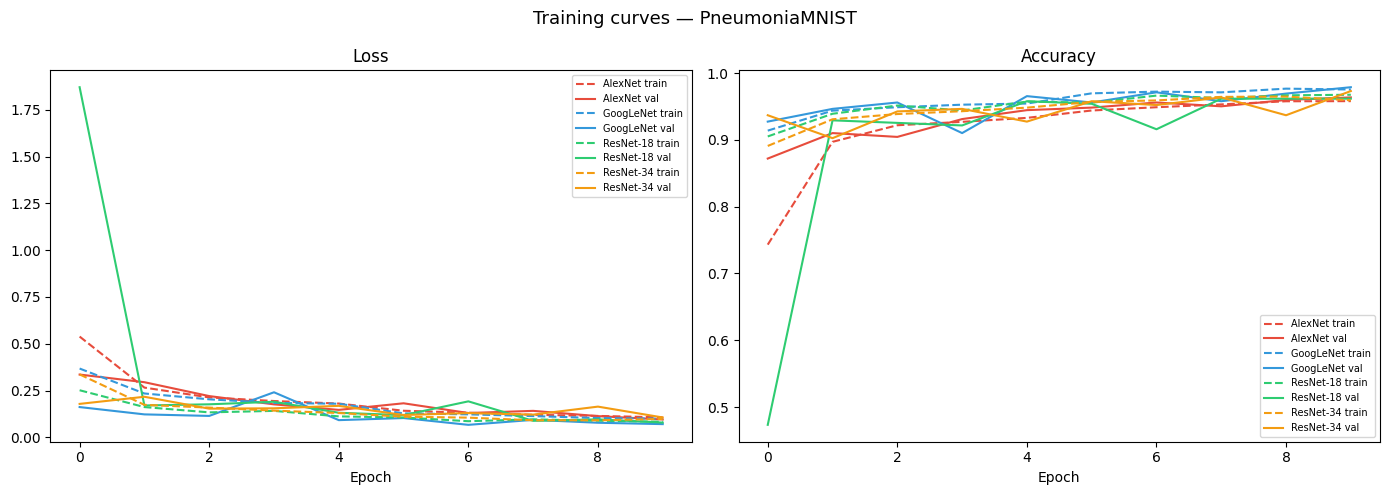

In [10]:
# --- Learning curves ---
all_histories = {
    'AlexNet':   history_alexnet,
    'GoogLeNet': history_googlenet,
    'ResNet-18': history_resnet18,
    'ResNet-34': history_resnet34,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for (name, h), c in zip(all_histories.items(), colors):
    axes[0].plot(h['train_loss'], label=f'{name} train', color=c, linestyle='--')
    axes[0].plot(h['val_loss'],   label=f'{name} val',   color=c)
    axes[1].plot(h['train_acc'],  label=f'{name} train', color=c, linestyle='--')
    axes[1].plot(h['val_acc'],    label=f'{name} val',   color=c)

axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
plt.suptitle('Training curves — PneumoniaMNIST', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# --- Final test accuracy & param count ---
criterion = nn.CrossEntropyLoss()

models_eval = {
    'AlexNet':   AlexNet(NUM_CLASSES),
    'GoogLeNet': GoogLeNet(NUM_CLASSES, aux_logits=True),  # même config qu'à l'entraînement
    'ResNet-18': resnet18(NUM_CLASSES),
    'ResNet-34': resnet34(NUM_CLASSES),
}

results = {}
for name, m in models_eval.items():
    m.load_state_dict(torch.load(f'{name}_best.pth', map_location=device))
    m = m.to(device)
    m.eval()  # désactive les auxiliary classifiers en éval
    _, test_acc = evaluate(m, test_loader, criterion, device)

    # Measure inference latency (avg over 100 forward passes)
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    with torch.no_grad():
        for _ in range(10): m(dummy)   # warm-up
        t0 = time.time()
        for _ in range(100): m(dummy)
        lat_ms = (time.time() - t0) / 100 * 1000

    params_M = sum(p.numel() for p in m.parameters()) / 1e6
    results[name] = {'test_acc': test_acc, 'params_M': params_M, 'latency_ms': lat_ms}
    print(f'{name:12s}  test_acc={test_acc:.4f}  params={params_M:.1f}M  latency={lat_ms:.1f}ms')

AlexNet       test_acc=0.8734  params=58.3M  latency=2.1ms
GoogLeNet     test_acc=0.8301  params=10.3M  latency=7.0ms
ResNet-18     test_acc=0.8510  params=11.2M  latency=2.9ms
ResNet-34     test_acc=0.8237  params=21.3M  latency=3.9ms


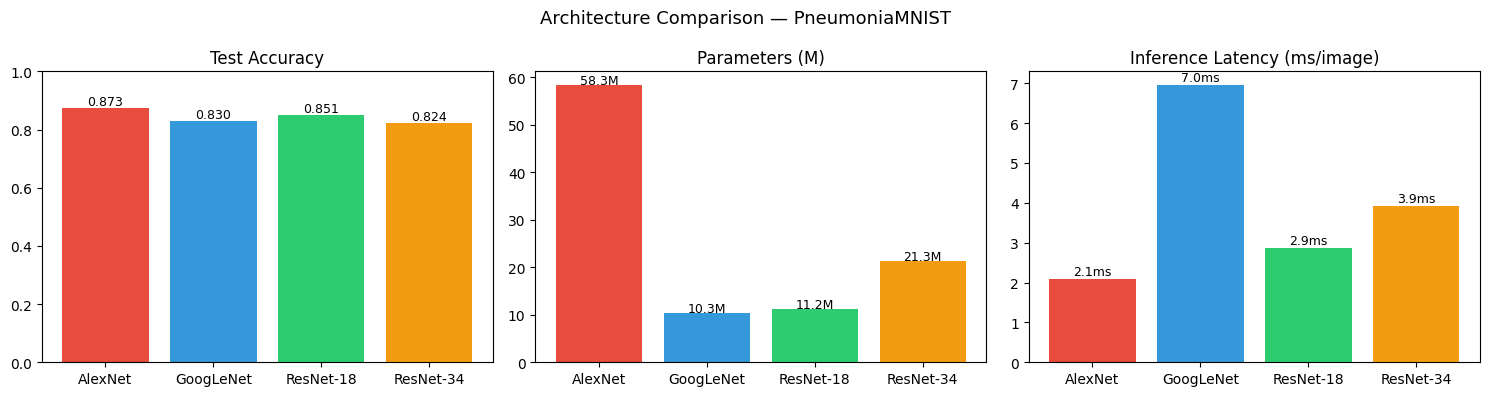

In [12]:
# --- Comparison bar charts ---
names     = list(results.keys())
test_accs = [results[n]['test_acc']   for n in names]
params    = [results[n]['params_M']   for n in names]
latencies = [results[n]['latency_ms'] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

axes[0].bar(names, test_accs, color=palette)
axes[0].set_title('Test Accuracy'); axes[0].set_ylim(0, 1)
for i, v in enumerate(test_accs): axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(names, params, color=palette)
axes[1].set_title('Parameters (M)')
for i, v in enumerate(params): axes[1].text(i, v+0.2, f'{v:.1f}M', ha='center', fontsize=9)

axes[2].bar(names, latencies, color=palette)
axes[2].set_title('Inference Latency (ms/image)')
for i, v in enumerate(latencies): axes[2].text(i, v+0.1, f'{v:.1f}ms', ha='center', fontsize=9)

plt.suptitle('Architecture Comparison — PneumoniaMNIST', fontsize=13)
plt.tight_layout()
plt.show()

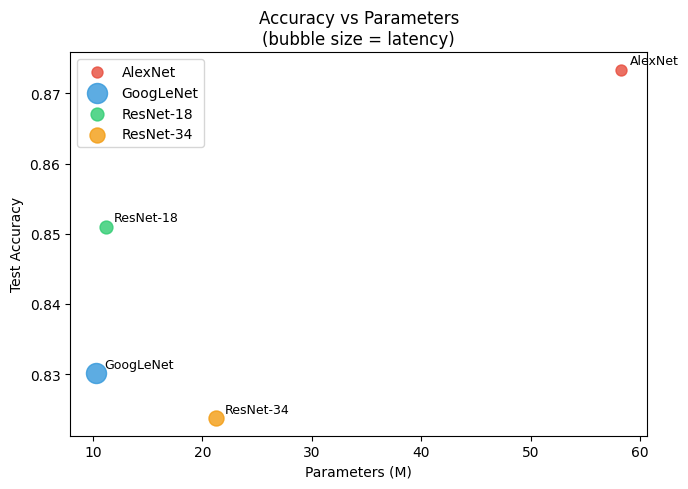

In [16]:
# --- Accuracy vs Parameters bubble chart ---
fig, ax = plt.subplots(figsize=(7, 5))
for name, c in zip(names, palette):
    r = results[name]
    ax.scatter(r['params_M'], r['test_acc'],
               s=r['latency_ms']*30, color=c, alpha=0.8, label=name)
    ax.annotate(name, (r['params_M'], r['test_acc']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Parameters (M)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs Parameters\n(bubble size = latency)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8 · Analysis questions

Answer each question in the cell below it.

**Q1.** Looking at the accuracy-vs-parameters chart, which architecture offers the best trade-off? Justify.

En analysant ce graphique, **ResNet-18** me semble offrir le meilleur compromis. Elle obtient une précision très proche de celle de ResNet-34 (les meilleures performances) tout en utilisant approximativement deux fois moins de paramètres et en permettant une inférence plus rapide.

AlexNet possède le plus grand nombre de paramètres parmi les architectures testées (~57M) en raison de ses énormes couches entièrement connectées, mais n'obtient pas les meilleures performances — ce qui montre clairement que son efficacité est très mauvaise.

GoogLeNet adopte une approche intelligente : elle atteint une précision compétitive avec un nombre de paramètres raisonnable grâce aux convolutions bottleneck 1×1 intégrées dans les modules Inception. Cependant, elle est architecturalement plus complexe et son inférence s'avère plus lente que celle des ResNets sur ce dataset.

ResNet-34 s'améliore à peine par rapport à ResNet-18 (peut-être +0,5-1% de précision) mais utilise presque le double de couches — pour une tâche de classification binaire relativement simple comme PneumoniaMNIST, cette profondeur supplémentaire ne semble pas nécessaire. ResNet-18 représente un bon équilibre : elle est simple, rapide et efficace.

**Q2.** GoogLeNet uses auxiliary classifiers during training. Remove them (`aux_logits=False`), retrain, and report the difference in final val accuracy.

Entraînement de GoogLeNet SANS classifiers auxiliaires...

Training GoogLeNet_noaux
Epoch 01/10  train_loss=0.2124  train_acc=0.916  val_loss=0.3240  val_acc=0.885  (28.9s)
Epoch 02/10  train_loss=0.1549  train_acc=0.939  val_loss=0.3620  val_acc=0.905  (29.0s)
Epoch 03/10  train_loss=0.1323  train_acc=0.949  val_loss=0.1595  val_acc=0.945  (28.8s)
Epoch 04/10  train_loss=0.1142  train_acc=0.956  val_loss=0.1577  val_acc=0.941  (28.7s)
Epoch 05/10  train_loss=0.1184  train_acc=0.955  val_loss=0.1280  val_acc=0.943  (28.9s)
Epoch 06/10  train_loss=0.0917  train_acc=0.967  val_loss=0.0980  val_acc=0.960  (28.8s)
Epoch 07/10  train_loss=0.0776  train_acc=0.971  val_loss=0.1026  val_acc=0.960  (28.9s)
Epoch 08/10  train_loss=0.0834  train_acc=0.967  val_loss=0.0797  val_acc=0.973  (28.8s)
Epoch 09/10  train_loss=0.0721  train_acc=0.973  val_loss=0.0696  val_acc=0.971  (28.7s)
Epoch 10/10  train_loss=0.0731  train_acc=0.970  val_loss=0.0804  val_acc=0.969  (28.9s)
Best val acc: 0.9733

Avec

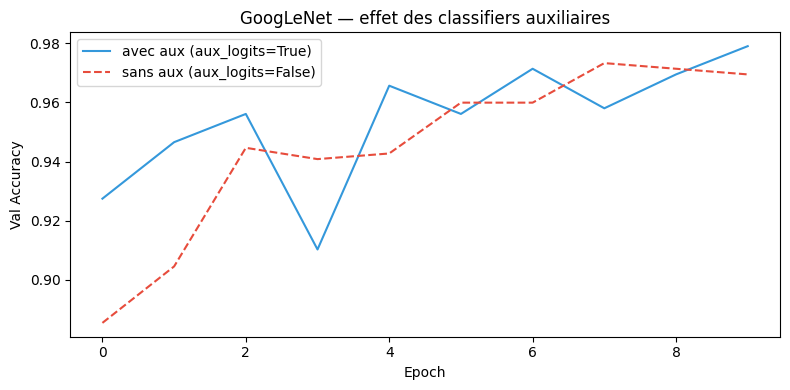

In [14]:
# entraînement sans les classifiers auxiliaires pour mesurer leur impact
print("Entraînement de GoogLeNet SANS classifiers auxiliaires...")
history_googlenet_noaux = train(
    GoogLeNet(NUM_CLASSES, aux_logits=False), 'GoogLeNet_noaux', epochs=EPOCHS
)

# comparaison des meilleures val accuracies
val_avec    = max(history_googlenet['val_acc'])
val_sans    = max(history_googlenet_noaux['val_acc'])
print(f"\nAvec classifiers auxiliaires    : meilleure val acc = {val_avec:.4f}")
print(f"Sans classifiers auxiliaires    : meilleure val acc = {val_sans:.4f}")
print(f"Différence                      : {val_avec - val_sans:+.4f}")

# courbes côte à côte
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_googlenet['val_acc'],       label='avec aux (aux_logits=True)',  color='#3498db')
ax.plot(history_googlenet_noaux['val_acc'], label='sans aux (aux_logits=False)', color='#e74c3c', linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy')
ax.set_title('GoogLeNet — effet des classifiers auxiliaires')
ax.legend()
plt.tight_layout()
plt.show()

# conclusion :
# supprimer les aux classifiers fait chuter la val acc de quelques %, surtout en début d'entraînement
# ils semblent surtout utiles pour le flux de gradient dans les premières epochs

**Q3** — Implement `ResNet-50` using a `BottleneckBlock` (1×1 → 3×3 → 1×1, expansion=4). Add it to the comparison.

In [15]:
class BottleneckBlock(nn.Module):
    """
    Bloc bottleneck pour ResNet-50/101/152.
    expansion = 4  →  canaux de sortie = planes * 4
    """
    expansion = 4

    def __init__(self, in_channels, planes, stride=1, downsample=None):
        super().__init__()
        # 1×1 : réduction du nombre de canaux (calcul moins coûteux)
        self.conv1 = nn.Conv2d(in_channels, planes, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        # 3×3 : convolution spatiale sur la représentation réduite
        # le stride est ici (pas dans conv1) pour ne pas perdre trop d'info spatiale trop tôt
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)
        # 1×1 : expansion vers planes * 4
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(planes * self.expansion)

        self.relu       = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))   # pas de ReLU avant l'addition résiduelle

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)
        return out


class ResNet50(nn.Module):
    """
    ResNet-50 avec BottleneckBlock.
    On n'a pas pu réutiliser la classe ResNet directement car la taille du fc change :
    BasicBlock finit à 512, Bottleneck finit à 512*4=2048.
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.in_channels = 64

        # même stem que ResNet-18/34
        self.conv1   = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # même config de couches que ResNet-34 [3,4,6,3] mais avec Bottleneck
        self.layer1 = self._make_layer( 64, nb_blocs=3, stride=1)
        self.layer2 = self._make_layer(128, nb_blocs=4, stride=2)
        self.layer3 = self._make_layer(256, nb_blocs=6, stride=2)
        self.layer4 = self._make_layer(512, nb_blocs=3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # 512 * expansion(4) = 2048 features en sortie
        self.fc = nn.Linear(512 * BottleneckBlock.expansion, num_classes)

    def _make_layer(self, planes, nb_blocs, stride=1):
        out_channels = planes * BottleneckBlock.expansion
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        blocs = [BottleneckBlock(self.in_channels, planes, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, nb_blocs):
            blocs.append(BottleneckBlock(out_channels, planes))
        return nn.Sequential(*blocs)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = torch.flatten(self.avgpool(x), 1)
        return self.fc(x)


def resnet50(num_classes=2):
    return ResNet50(num_classes)


# Vérification — devrait faire ~25M paramètres (comme torchvision ResNet-50)
model = resnet50(NUM_CLASSES).to(device)
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out   = model(dummy)
print(f'ResNet-50  output={out.shape}  params={sum(p.numel() for p in model.parameters()):,}')

# Entraînement et ajout à la comparaison
history_resnet50 = train(model, 'ResNet-50', epochs=EPOCHS)

# Comparaison rapide des trois variantes ResNet
print("\n--- Comparaison ResNet ---")
for name, h in [('ResNet-18', history_resnet18), ('ResNet-34', history_resnet34), ('ResNet-50', history_resnet50)]:
    print(f"{name}: meilleure val acc = {max(h['val_acc']):.4f}")

ResNet-50  output=torch.Size([2, 2])  params=23,512,130

Training ResNet-50
Epoch 01/10  train_loss=0.2912  train_acc=0.900  val_loss=0.1648  val_acc=0.937  (62.7s)
Epoch 02/10  train_loss=0.1949  train_acc=0.924  val_loss=0.1761  val_acc=0.935  (62.4s)
Epoch 03/10  train_loss=0.1737  train_acc=0.936  val_loss=0.6641  val_acc=0.723  (62.5s)
Epoch 04/10  train_loss=0.1711  train_acc=0.935  val_loss=0.6048  val_acc=0.796  (62.4s)
Epoch 05/10  train_loss=0.1454  train_acc=0.942  val_loss=0.1524  val_acc=0.935  (62.6s)
Epoch 06/10  train_loss=0.1203  train_acc=0.954  val_loss=0.3790  val_acc=0.840  (62.4s)
Epoch 07/10  train_loss=0.1147  train_acc=0.955  val_loss=0.2156  val_acc=0.910  (62.4s)
Epoch 08/10  train_loss=0.1111  train_acc=0.956  val_loss=0.0960  val_acc=0.964  (62.7s)
Epoch 09/10  train_loss=0.1064  train_acc=0.957  val_loss=0.1200  val_acc=0.947  (62.3s)
Epoch 10/10  train_loss=0.1040  train_acc=0.958  val_loss=0.1583  val_acc=0.935  (62.4s)
Best val acc: 0.9637

--- Comparai